<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/NYC_JobPostings_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Getting the Data**

In [59]:
!pip install sodapy
import pandas as pd
import numpy as np
import matplotlib.pyplot as mpl
from sodapy import Socrata

In [60]:
baseURL = 'data.cityofnewyork.us'
appToken = 'nBJSuGlevkRfP1fiItRJ55RrM'
time = 60

dataset = 'kpav-sd4t' #NYC Job Postings
chunk = 5000  #Rows

In [61]:
restInspection = Socrata(baseURL, appToken, timeout = time)
restData = restInspection.get(dataset, limit=chunk)

In [62]:
restDF = pd.DataFrame(restData) #Save as a Dataframe
restDF.head()

,job_id,agency,posting_type,number_of_positions,business_title,civil_service_title,title_classification,title_code_no,level,job_category,...,to_apply,work_location_1,residency_requirement,posting_date,post_until,posting_updated,process_date,preferred_skills,additional_information,hours_shift
0,776702,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Water Supply Control Center Operator,WATERSHED MAINTAINER,Competitive-1,91011,00,Building Operations & Maintenance,...,"To apply, click apply now.","7870 State Rd 42 Grahamsville,",New York City residency is not required for th...,2026-04-08T00:00:00.000,07-JUN-2026,2026-04-08T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
1,780047,DISTRICT ATTORNEY-MANHATTAN,Internal,1,e-Discovery Data Specialist,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,"Technology, Data & Innovation",...,NaN,"1 Hogan Pl./100 Centre St., N.",City Residency is not required for this position,2026-05-05T00:00:00.000,04-JUL-2026,2026-05-06T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2,780232,HOUSING PRESERVATION & DVLPMNT,External,1,"Assistant Commissioner, Division of New Constr...",ASSISTANT COMMISSIONER (ALTERN,Non-Competitive-5,95549,M3,Constituent Services & Community Programs,...,NaN,100 Gold Street,New York City residency is generally required ...,2026-05-07T00:00:00.000,06-JUN-2026,2026-05-07T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
3,709486,DEPT OF HEALTH/MENTAL HYGIENE,External,2,"Public Health Inspector, Bureau of Food Safety...",PUBLIC HEALTH SANITARIAN,Competitive-1,31215,01,"Public Safety, Inspections, & Enforcement",...,NaN,NYC - All Boroughs,New York City residency is generally required ...,2026-04-28T00:00:00.000,27-JUN-2026,2026-05-04T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
4,767717,DEPT OF ENVIRONMENT PROTECTION,External,1,DESIGN ENGINEER 2,MECHANICAL ENGINEER,Competitive-1,20415,01,"Engineering, Architecture, & Planning",...,NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-30T00:00:00.000,29-JUN-2026,2026-04-30T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN


In [63]:
restDF.to_csv('JobsNYCPostings.csv') #Saving locally as a CSV

In [64]:
#Formatting as Float
pd.options.display.float_format = '{:.2f}'.format

In [65]:
print(restDF.shape)

(2373, 29)


**Cleaning the Data**

In [66]:
#Check for duplicates, and which rows are duplacted
duplicates = restDF.duplicated()
duplicates[duplicates == True]

,0
78,True
212,True
220,True
468,True
640,True
1101,True
1165,True
1332,True
1646,True
1959,True


In [67]:
#Remove Duplicates
restDF.drop_duplicates(inplace = True)  #Inplace argument will edit the original DF directly
restDF #Check if rows have been dropped


,job_id,agency,posting_type,number_of_positions,business_title,civil_service_title,title_classification,title_code_no,level,job_category,...,to_apply,work_location_1,residency_requirement,posting_date,post_until,posting_updated,process_date,preferred_skills,additional_information,hours_shift
0,776702,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Water Supply Control Center Operator,WATERSHED MAINTAINER,Competitive-1,91011,00,Building Operations & Maintenance,...,"To apply, click apply now.","7870 State Rd 42 Grahamsville,",New York City residency is not required for th...,2026-04-08T00:00:00.000,07-JUN-2026,2026-04-08T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
1,780047,DISTRICT ATTORNEY-MANHATTAN,Internal,1,e-Discovery Data Specialist,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,"Technology, Data & Innovation",...,NaN,"1 Hogan Pl./100 Centre St., N.",City Residency is not required for this position,2026-05-05T00:00:00.000,04-JUL-2026,2026-05-06T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2,780232,HOUSING PRESERVATION & DVLPMNT,External,1,"Assistant Commissioner, Division of New Constr...",ASSISTANT COMMISSIONER (ALTERN,Non-Competitive-5,95549,M3,Constituent Services & Community Programs,...,NaN,100 Gold Street,New York City residency is generally required ...,2026-05-07T00:00:00.000,06-JUN-2026,2026-05-07T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
3,709486,DEPT OF HEALTH/MENTAL HYGIENE,External,2,"Public Health Inspector, Bureau of Food Safety...",PUBLIC HEALTH SANITARIAN,Competitive-1,31215,01,"Public Safety, Inspections, & Enforcement",...,NaN,NYC - All Boroughs,New York City residency is generally required ...,2026-04-28T00:00:00.000,27-JUN-2026,2026-05-04T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
4,767717,DEPT OF ENVIRONMENT PROTECTION,External,1,DESIGN ENGINEER 2,MECHANICAL ENGINEER,Competitive-1,20415,01,"Engineering, Architecture, & Planning",...,NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-30T00:00:00.000,29-JUN-2026,2026-04-30T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,774850,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"HRU Data Associate, Bureau of Alcohol and Drug...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,01,"Policy, Research & Analysis",...,NaN,42-09 28th Street,New York City residency is generally required ...,2026-03-20T00:00:00.000,19-MAY-2026,2026-04-09T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2369,752400,DISTRICT ATTORNEY-MANHATTAN,External,8,GJ Stenographer,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,Legal Affairs,...,NaN,"1 Hogan Pl./100 Centre St., N.",•\tMust be a U.S. citizen and reside in one of...,2026-04-07T00:00:00.000,04-JUN-2026,2026-04-07T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2370,767778,DEPT OF ENVIRONMENT PROTECTION,Internal,1,EHS REGIONAL MANAGER,CONSTRUCTION PROJECT MANAGER,Competitive-1,34202,03,"Engineering, Architecture, & Planning Public S...",...,NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-14T00:00:00.000,13-JUN-2026,2026-04-13T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2371,779717,DEPARTMENT OF TRANSPORTATION,Internal,1,College Aide – Ferries ENG Division,COLLEGE AIDE (ALL CITY DEPTS),Non-Competitive-5,10209,01,"Engineering, Architecture, & Planning",...,TO APPLY: Please visit www.nyc.gov/careers/se...,"1 Bay St., S.I.,Ny",New York City residency is generally required ...,2026-05-06T00:00:00.000,27-MAY-2026,2026-05-07T00:00:00.000,2026-05-18T00:00:00.000,PREFERRED SKILLS 1. Experience with Microsoft ...,ADDITIONAL INFORMATION: TWIC REQUIREMENT: Once...,NaN


In [68]:
print(restDF.shape) #Number of rows has changed, meaning duplicates were dropped successfully

(2362, 29)


In [69]:

restDF.columns

Index(['job_id', 'agency', 'posting_type', 'number_of_positions',
       'business_title', 'civil_service_title', 'title_classification',
       'title_code_no', 'level', 'job_category',
       'full_time_part_time_indicator', 'career_level', 'salary_range_from',
       'salary_range_to', 'salary_frequency', 'work_location',
       'division_work_unit', 'job_description', 'minimum_qual_requirements',
       'to_apply', 'work_location_1', 'residency_requirement', 'posting_date',
       'post_until', 'posting_updated', 'process_date', 'preferred_skills',
       'additional_information', 'hours_shift'],
      dtype='object')

In [70]:
restDF.head()

,job_id,agency,posting_type,number_of_positions,business_title,civil_service_title,title_classification,title_code_no,level,job_category,...,to_apply,work_location_1,residency_requirement,posting_date,post_until,posting_updated,process_date,preferred_skills,additional_information,hours_shift
0,776702,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Water Supply Control Center Operator,WATERSHED MAINTAINER,Competitive-1,91011,00,Building Operations & Maintenance,...,"To apply, click apply now.","7870 State Rd 42 Grahamsville,",New York City residency is not required for th...,2026-04-08T00:00:00.000,07-JUN-2026,2026-04-08T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
1,780047,DISTRICT ATTORNEY-MANHATTAN,Internal,1,e-Discovery Data Specialist,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,"Technology, Data & Innovation",...,NaN,"1 Hogan Pl./100 Centre St., N.",City Residency is not required for this position,2026-05-05T00:00:00.000,04-JUL-2026,2026-05-06T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
2,780232,HOUSING PRESERVATION & DVLPMNT,External,1,"Assistant Commissioner, Division of New Constr...",ASSISTANT COMMISSIONER (ALTERN,Non-Competitive-5,95549,M3,Constituent Services & Community Programs,...,NaN,100 Gold Street,New York City residency is generally required ...,2026-05-07T00:00:00.000,06-JUN-2026,2026-05-07T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
3,709486,DEPT OF HEALTH/MENTAL HYGIENE,External,2,"Public Health Inspector, Bureau of Food Safety...",PUBLIC HEALTH SANITARIAN,Competitive-1,31215,01,"Public Safety, Inspections, & Enforcement",...,NaN,NYC - All Boroughs,New York City residency is generally required ...,2026-04-28T00:00:00.000,27-JUN-2026,2026-05-04T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN
4,767717,DEPT OF ENVIRONMENT PROTECTION,External,1,DESIGN ENGINEER 2,MECHANICAL ENGINEER,Competitive-1,20415,01,"Engineering, Architecture, & Planning",...,NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-30T00:00:00.000,29-JUN-2026,2026-04-30T00:00:00.000,2026-05-18T00:00:00.000,NaN,NaN,NaN


In [71]:
for column in restDF.columns:
  if restDF[column].isna().all() or restDF[column].nunique()==1:
    print(column)

process_date


In [72]:
print(restDF['process_date'])

0       2026-05-18T00:00:00.000
1       2026-05-18T00:00:00.000
2       2026-05-18T00:00:00.000
3       2026-05-18T00:00:00.000
4       2026-05-18T00:00:00.000
                 ...           
2368    2026-05-18T00:00:00.000
2369    2026-05-18T00:00:00.000
2370    2026-05-18T00:00:00.000
2371    2026-05-18T00:00:00.000
2372    2026-05-18T00:00:00.000
Name: process_date, Length: 2362, dtype: object


In [73]:
restDF.drop(columns=['process_date'], inplace=True)
#This column was dropped because all values were the same: 2026-05-18T00:00:00.000.
restDF.head()

,job_id,agency,posting_type,number_of_positions,business_title,civil_service_title,title_classification,title_code_no,level,job_category,...,minimum_qual_requirements,to_apply,work_location_1,residency_requirement,posting_date,post_until,posting_updated,preferred_skills,additional_information,hours_shift
0,776702,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Water Supply Control Center Operator,WATERSHED MAINTAINER,Competitive-1,91011,00,Building Operations & Maintenance,...,A four-year high school diploma or its educati...,"To apply, click apply now.","7870 State Rd 42 Grahamsville,",New York City residency is not required for th...,2026-04-08T00:00:00.000,07-JUN-2026,2026-04-08T00:00:00.000,NaN,NaN,NaN
1,780047,DISTRICT ATTORNEY-MANHATTAN,Internal,1,e-Discovery Data Specialist,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,"Technology, Data & Innovation",...,1. A baccalaureate degree from an accredited c...,NaN,"1 Hogan Pl./100 Centre St., N.",City Residency is not required for this position,2026-05-05T00:00:00.000,04-JUL-2026,2026-05-06T00:00:00.000,NaN,NaN,NaN
2,780232,HOUSING PRESERVATION & DVLPMNT,External,1,"Assistant Commissioner, Division of New Constr...",ASSISTANT COMMISSIONER (ALTERN,Non-Competitive-5,95549,M3,Constituent Services & Community Programs,...,Minimum Qualification Requirements 1. A bacca...,NaN,100 Gold Street,New York City residency is generally required ...,2026-05-07T00:00:00.000,06-JUN-2026,2026-05-07T00:00:00.000,NaN,NaN,NaN
3,709486,DEPT OF HEALTH/MENTAL HYGIENE,External,2,"Public Health Inspector, Bureau of Food Safety...",PUBLIC HEALTH SANITARIAN,Competitive-1,31215,01,"Public Safety, Inspections, & Enforcement",...,1. A baccalaureate degree from an accredited c...,NaN,NYC - All Boroughs,New York City residency is generally required ...,2026-04-28T00:00:00.000,27-JUN-2026,2026-05-04T00:00:00.000,NaN,NaN,NaN
4,767717,DEPT OF ENVIRONMENT PROTECTION,External,1,DESIGN ENGINEER 2,MECHANICAL ENGINEER,Competitive-1,20415,01,"Engineering, Architecture, & Planning",...,"(1) Four (4) years of full-time, satisfactory ...",NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-30T00:00:00.000,29-JUN-2026,2026-04-30T00:00:00.000,NaN,NaN,NaN


In [74]:
missing_values = restDF.isnull().sum()
missing_percentage = (missing_values / len(restDF)) * 100

# Display columns with their missing percentage, sorted in descending order.
print("Percentage of Missing Values Per Column:")
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Percentage of Missing Values Per Column:


,0
hours_shift,87.17
additional_information,72.86
to_apply,60.25
preferred_skills,49.49
post_until,1.99
minimum_qual_requirements,1.31


In [75]:
#Replace the "Not Available" test with NA so we can use FillNA later for numerical values.
restDF.replace('Not Available', pd.NA, inplace=True)
restDF

,job_id,agency,posting_type,number_of_positions,business_title,civil_service_title,title_classification,title_code_no,level,job_category,...,minimum_qual_requirements,to_apply,work_location_1,residency_requirement,posting_date,post_until,posting_updated,preferred_skills,additional_information,hours_shift
0,776702,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Water Supply Control Center Operator,WATERSHED MAINTAINER,Competitive-1,91011,00,Building Operations & Maintenance,...,A four-year high school diploma or its educati...,"To apply, click apply now.","7870 State Rd 42 Grahamsville,",New York City residency is not required for th...,2026-04-08T00:00:00.000,07-JUN-2026,2026-04-08T00:00:00.000,NaN,NaN,NaN
1,780047,DISTRICT ATTORNEY-MANHATTAN,Internal,1,e-Discovery Data Specialist,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,"Technology, Data & Innovation",...,1. A baccalaureate degree from an accredited c...,NaN,"1 Hogan Pl./100 Centre St., N.",City Residency is not required for this position,2026-05-05T00:00:00.000,04-JUL-2026,2026-05-06T00:00:00.000,NaN,NaN,NaN
2,780232,HOUSING PRESERVATION & DVLPMNT,External,1,"Assistant Commissioner, Division of New Constr...",ASSISTANT COMMISSIONER (ALTERN,Non-Competitive-5,95549,M3,Constituent Services & Community Programs,...,Minimum Qualification Requirements 1. A bacca...,NaN,100 Gold Street,New York City residency is generally required ...,2026-05-07T00:00:00.000,06-JUN-2026,2026-05-07T00:00:00.000,NaN,NaN,NaN
3,709486,DEPT OF HEALTH/MENTAL HYGIENE,External,2,"Public Health Inspector, Bureau of Food Safety...",PUBLIC HEALTH SANITARIAN,Competitive-1,31215,01,"Public Safety, Inspections, & Enforcement",...,1. A baccalaureate degree from an accredited c...,NaN,NYC - All Boroughs,New York City residency is generally required ...,2026-04-28T00:00:00.000,27-JUN-2026,2026-05-04T00:00:00.000,NaN,NaN,NaN
4,767717,DEPT OF ENVIRONMENT PROTECTION,External,1,DESIGN ENGINEER 2,MECHANICAL ENGINEER,Competitive-1,20415,01,"Engineering, Architecture, & Planning",...,"(1) Four (4) years of full-time, satisfactory ...",NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-30T00:00:00.000,29-JUN-2026,2026-04-30T00:00:00.000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,774850,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"HRU Data Associate, Bureau of Alcohol and Drug...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,01,"Policy, Research & Analysis",...,"1. For Assignment Level I (only physical, bio...",NaN,42-09 28th Street,New York City residency is generally required ...,2026-03-20T00:00:00.000,19-MAY-2026,2026-04-09T00:00:00.000,NaN,NaN,NaN
2369,752400,DISTRICT ATTORNEY-MANHATTAN,External,8,GJ Stenographer,COMMUNITY COORDINATOR,Non-Competitive-5,56058,00,Legal Affairs,...,1. A baccalaureate degree from an accredited c...,NaN,"1 Hogan Pl./100 Centre St., N.",•\tMust be a U.S. citizen and reside in one of...,2026-04-07T00:00:00.000,04-JUN-2026,2026-04-07T00:00:00.000,NaN,NaN,NaN
2370,767778,DEPT OF ENVIRONMENT PROTECTION,Internal,1,EHS REGIONAL MANAGER,CONSTRUCTION PROJECT MANAGER,Competitive-1,34202,03,"Engineering, Architecture, & Planning Public S...",...,1. A four-year high school diploma or its educ...,NaN,96-05 Horace Harding Expway,New York City Residency is not required for th...,2026-04-14T00:00:00.000,13-JUN-2026,2026-04-13T00:00:00.000,NaN,NaN,NaN
2371,779717,DEPARTMENT OF TRANSPORTATION,Internal,1,College Aide – Ferries ENG Division,COLLEGE AIDE (ALL CITY DEPTS),Non-Competitive-5,10209,01,"Engineering, Architecture, & Planning",...,For Assignment Level I: Matriculation at an a...,TO APPLY: Please visit www.nyc.gov/careers/se...,"1 Bay St., S.I.,Ny",New York City residency is generally required ...,2026-05-06T00:00:00.000,27-MAY-2026,2026-05-07T00:00:00.000,PREFERRED SKILLS 1. Experience with Microsoft ...,ADDITIONAL INFORMATION: TWIC REQUIREMENT: Once...,NaN


In [76]:

restDF.columns


Index(['job_id', 'agency', 'posting_type', 'number_of_positions',
       'business_title', 'civil_service_title', 'title_classification',
       'title_code_no', 'level', 'job_category',
       'full_time_part_time_indicator', 'career_level', 'salary_range_from',
       'salary_range_to', 'salary_frequency', 'work_location',
       'division_work_unit', 'job_description', 'minimum_qual_requirements',
       'to_apply', 'work_location_1', 'residency_requirement', 'posting_date',
       'post_until', 'posting_updated', 'preferred_skills',
       'additional_information', 'hours_shift'],
      dtype='object')

**Analyzing the Data**

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Required Data Transformation Pipeline
# 1. Cast numeric financial and staffing dimensions to float
numeric_cols = ['number_of_positions', 'salary_range_from', 'salary_range_to']
for col in numeric_cols:
    restDF[col] = pd.to_numeric(restDF[col], errors='coerce')

# 2. Convert raw posting timestamps to datetime objects
restDF['posting_date'] = pd.to_datetime(restDF['posting_date'], errors='coerce')

In [78]:
restDF.describe()

,number_of_positions,salary_range_from,salary_range_to,posting_date
count,2362.00,2362.00,2362.00,2362
mean,2.62,71524.62,93239.97,2026-04-22 05:51:09.602032128
min,1.00,0.00,17.25,2025-06-24 00:00:00
25%,1.00,55105.00,68709.00,2026-04-09 00:00:00
50%,1.00,68213.00,90000.00,2026-04-27 00:00:00
75%,1.00,86837.25,114411.00,2026-05-08 00:00:00
max,243.00,385000.00,415000.00,2026-05-18 00:00:00
std,11.10,39599.19,50524.47,NaN


In [79]:
# Select key operational and financial metrics for analysis
selected_columns = ['number_of_positions', 'salary_range_from', 'salary_range_to']
summary_stats = restDF[selected_columns].describe()
print(summary_stats)

       number_of_positions  salary_range_from  salary_range_to
count              2362.00            2362.00          2362.00
mean                  2.62           71524.62         93239.97
std                  11.10           39599.19         50524.47
min                   1.00               0.00            17.25
25%                   1.00           55105.00         68709.00
50%                   1.00           68213.00         90000.00
75%                   1.00           86837.25        114411.00
max                 243.00          385000.00        415000.00


*What is the structural dispersion between entry-level compensation baselines and executive civil service caps across active municipal openings, and how severely do differing wage frequencies distort these metrics?*

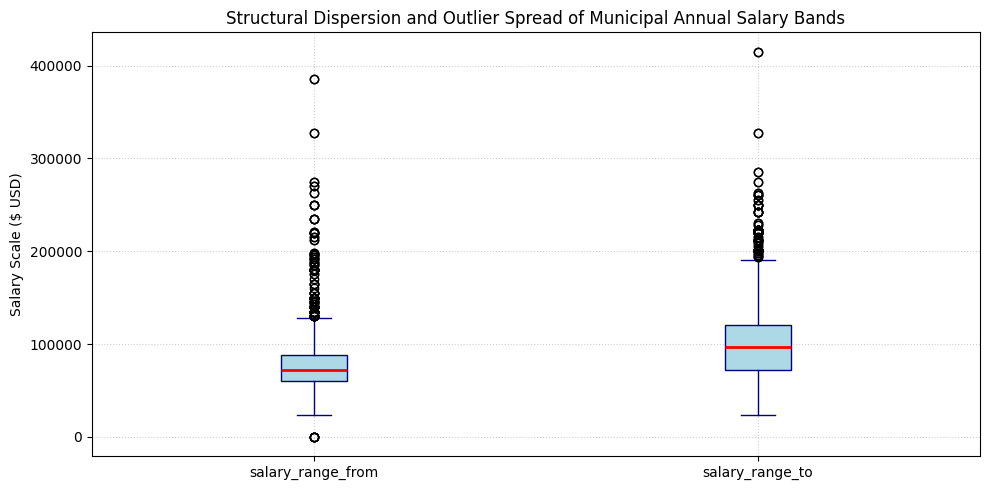

In [80]:
#VISUALIZATION: Dual-Boxplot Distribution Analysis
plt.figure(figsize=(10, 5))
annual_salaries = restDF[restDF['salary_frequency'] == 'Annual']
annual_salaries[['salary_range_from', 'salary_range_to']].boxplot(patch_artist=True,
                                                                 boxprops=dict(facecolor='lightblue', color='navy'),
                                                                 whiskerprops=dict(color='navy'),
                                                                 capprops=dict(color='navy'),
                                                                 medianprops=dict(color='red', linewidth=2))
plt.ylabel("Salary Scale ($ USD)")
plt.title("Structural Dispersion and Outlier Spread of Municipal Annual Salary Bands")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

*How heavily is NYC’s public sector human capital centralized within the Manhattan administrative core versus the frontline operational hubs of the outer boroughs?*

                       total_openings  median_max_salary
work_location_borough                                   
Other/Outside NYC                4062           90551.00
Bronx                             727           84500.00
Manhattan                         437           77500.00
Queens                            367          107656.00
Brooklyn                          322           86735.50
All Boroughs                      256           61102.00
Staten Island                       6              28.61


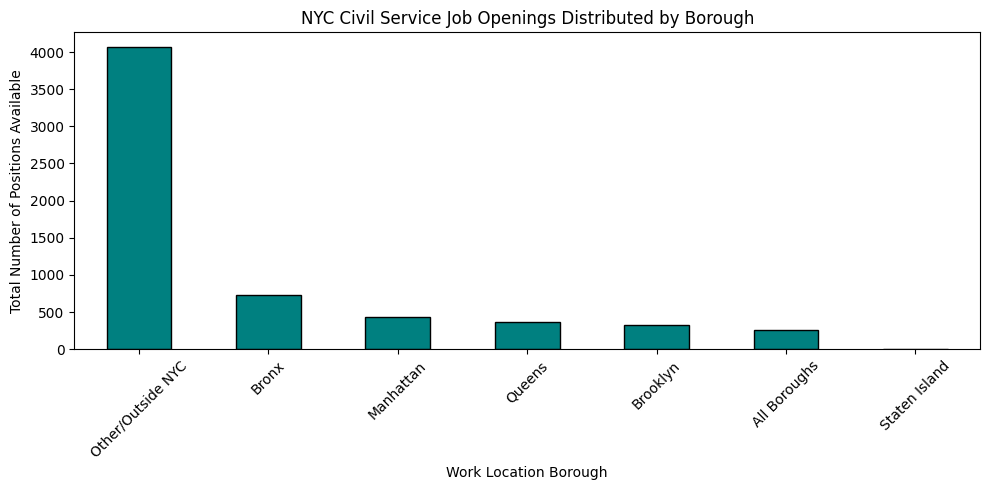

In [81]:
def extract_borough(location):
    if pd.isna(location):
        return 'Unknown'
    location = str(location).lower()
    if 'manhattan' in location or '100 centre st' in location or 'gold street' in location:
        return 'Manhattan'
    elif 'bronx' in location:
        return 'Bronx'
    elif 'brooklyn' in location:
        return 'Brooklyn'
    elif 'queens' in location or 'horace harding expway' in location:
        return 'Queens'
    elif 'staten island' in location:
        return 'Staten Island'
    elif 'all boroughs' in location or 'nyc - all boroughs' in location:
        return 'All Boroughs'
    else:
        return 'Other/Outside NYC'

restDF['work_location_borough'] = restDF['work_location_1'].apply(extract_borough)

# Aggregate total positions open and median maximum salary by borough
geo_analysis = restDF.groupby('work_location_borough').agg(
    total_openings=('number_of_positions', 'sum'),
    median_max_salary=('salary_range_to', 'median')
).sort_values(by='total_openings', ascending=False)

print(geo_analysis)

# Plot the geographical concentration of postings
plt.figure(figsize=(10, 5))
geo_analysis['total_openings'].plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel("Work Location Borough")
plt.ylabel("Total Number of Positions Available")
plt.title("NYC Civil Service Job Openings Distributed by Borough")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Does citywide talent acquisition exhibit cyclical spikes tied directly to the July 1st fiscal year budget adoption, or does recruitment operate on a frictionless, continuous demand structure?*

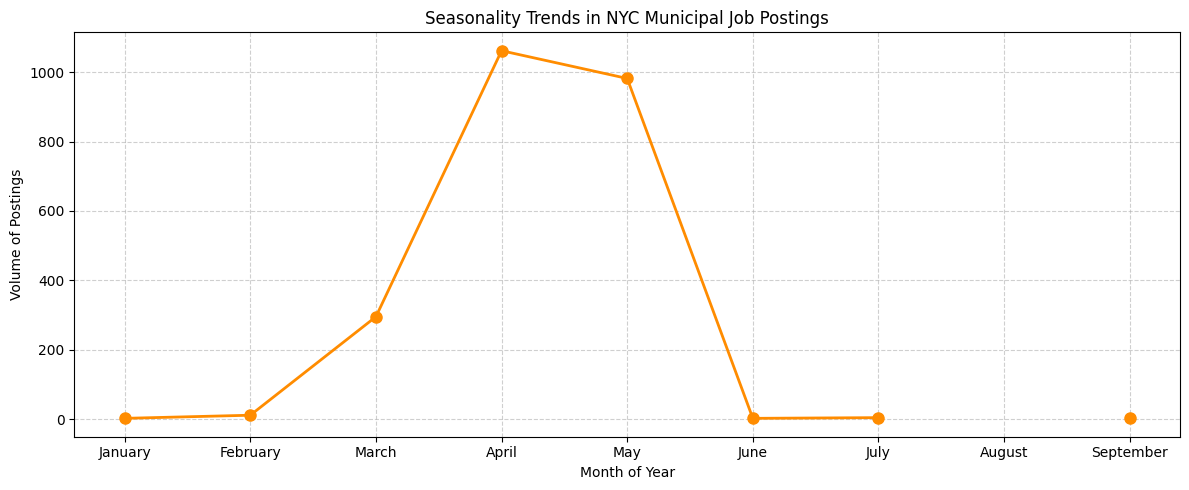

In [82]:
# Extract temporal components
restDF['posting_month'] = restDF['posting_date'].dt.strftime('%B')
restDF['day_of_week'] = restDF['posting_date'].dt.day_name()

# Order months chronologically for the plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

temporal_month = restDF['posting_month'].value_counts().reindex(month_order)

# Plotting the temporal seasonality
plt.figure(figsize=(12, 5))
temporal_month.plot(kind='line', marker='o', color='darkorange', linewidth=2, markersize=8)
plt.xlabel("Month of Year")
plt.ylabel("Volume of Postings")
plt.title("Seasonality Trends in NYC Municipal Job Postings")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

*Which municipal agencies act as the primary drivers of localized labor demand, and how heavily do their recruitment pipelines prioritize internal civil service advancement over open-market talent acquisition?*

Top 10 Hiring Agencies:
agency
DEPT OF HEALTH/MENTAL HYGIENE     452
DEPT OF ENVIRONMENT PROTECTION    219
DEPT OF DESIGN & CONSTRUCTION     159
DEPARTMENT OF TRANSPORTATION      152
HRA/DEPT OF SOCIAL SERVICES       126
NYC HOUSING AUTHORITY             124
HOUSING PRESERVATION & DVLPMNT    121
BRONX DISTRICT ATTORNEY            80
ADMIN FOR CHILDREN'S SVCS          72
DISTRICT ATTORNEY-MANHATTAN        71
Name: count, dtype: int64


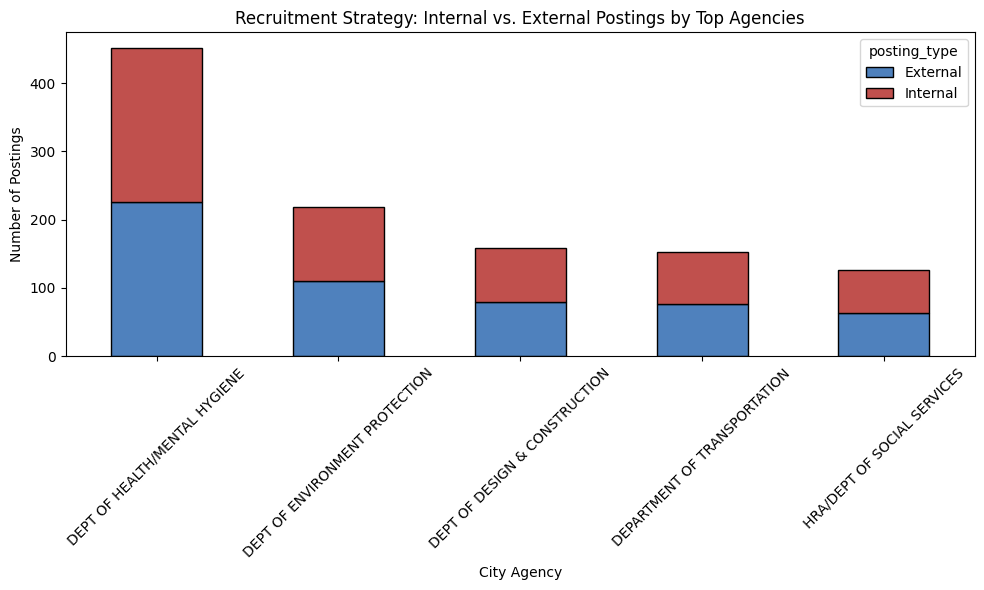

In [83]:
# Top 10 hiring agencies by posting volume
print("Top 10 Hiring Agencies:")
print(restDF['agency'].value_counts().head(10))

# Sourcing mix analysis (Internal vs. External Recruitment pipelines)
pipeline_mix = restDF.groupby(['agency', 'posting_type']).size().unstack(fill_value=0)
top_5_agencies_mix = pipeline_mix.loc[restDF['agency'].value_counts().head(5).index]

# Visualizing pipeline structure
top_5_agencies_mix.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4F81BD', '#C0504D'], edgecolor='black')
plt.xlabel("City Agency")
plt.ylabel("Number of Postings")
plt.title("Recruitment Strategy: Internal vs. External Postings by Top Agencies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Has the operational velocity of civil service fulfillment slowed down over consecutive fiscal years, resulting in a compounding backlog of unfulfilled institutional vacancies, and if so, how does this vacancy backlog aging evolve across seasonal fiscal quarters?*

Average Posting Backlog/Age (Days) by Calendar Year:
posting_year
2025   293.00
2026    29.64
Name: posting_age_days, dtype: float64

Evolution of Vacancy Backlog Lifespan Across Sequential Fiscal Quarters:
posting_quarter
2025Q2   333.00
2025Q3   283.00
2026Q1    60.94
2026Q2    24.92
Freq: Q-DEC, Name: posting_age_days, dtype: float64


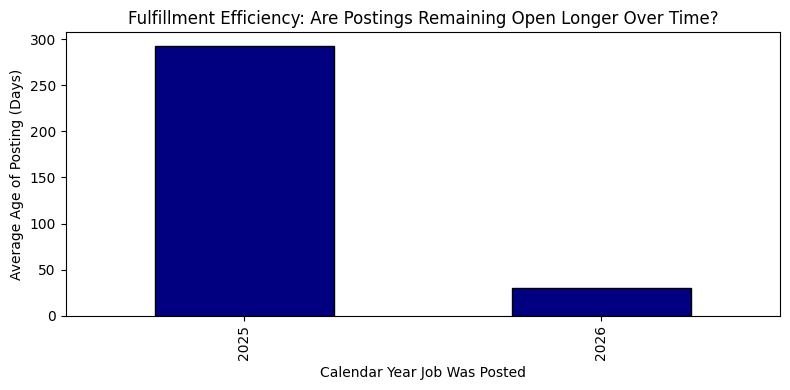

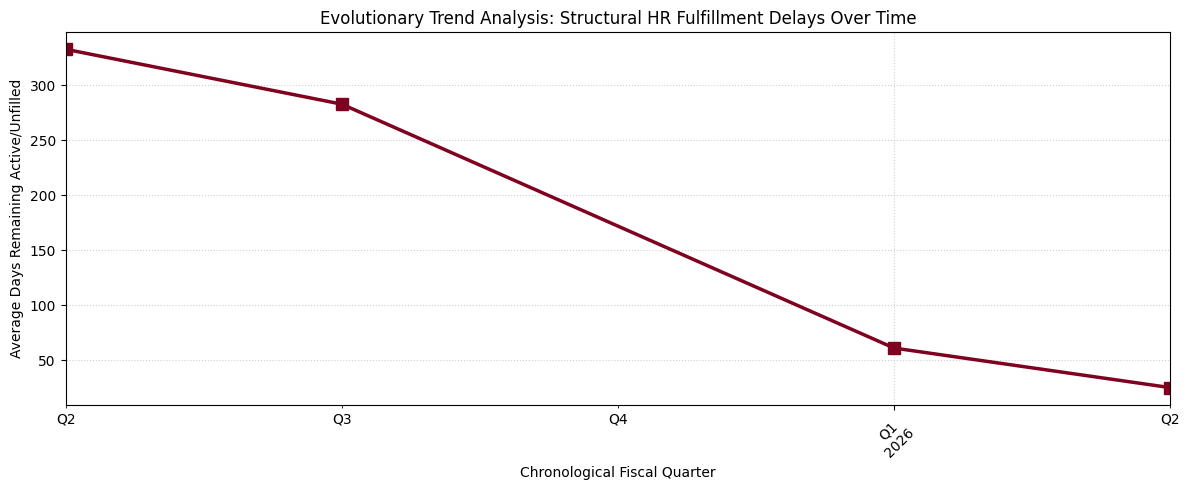

In [84]:
# Set baseline project assessment date to evaluate posting velocity
analysis_baseline_date = pd.to_datetime('2026-05-23')

# 1. Create the fundamental calculated column: Days a posting has been live/active
restDF['posting_age_days'] = (analysis_baseline_date - restDF['posting_date']).dt.days

# 2. Analyze historical trend: Is the average backlog age increasing over calendar years?
restDF['posting_year'] = restDF['posting_date'].dt.year
yearly_velocity = restDF.groupby('posting_year')['posting_age_days'].mean()

print("Average Posting Backlog/Age (Days) by Calendar Year:")
print(yearly_velocity)

# 3. Analyze seasonal evolution: Grouping by Fiscal Quarters to trace operational backlog trends
restDF['posting_quarter'] = restDF['posting_date'].dt.to_period('Q')
quarterly_evolution = restDF.groupby('posting_quarter')['posting_age_days'].mean().sort_index()

print("\nEvolution of Vacancy Backlog Lifespan Across Sequential Fiscal Quarters:")
print(quarterly_evolution)

# Annual Fulfillment Efficiency Trajectory
plt.figure(figsize=(8, 4))
yearly_velocity.plot(kind='bar', color='navy', edgecolor='black')
plt.xlabel("Calendar Year Job Was Posted")
plt.ylabel("Average Age of Posting (Days)")
plt.title("Fulfillment Efficiency: Are Postings Remaining Open Longer Over Time?")
plt.tight_layout()
plt.show()

# Chronological Backlog Evolution Trend Line
plt.figure(figsize=(12, 5))
quarterly_evolution.plot(kind='line', marker='s', color='#800020', linewidth=2.5, markersize=8)
plt.xlabel("Chronological Fiscal Quarter")
plt.ylabel("Average Days Remaining Active/Unfilled")
plt.title("Evolutionary Trend Analysis: Structural HR Fulfillment Delays Over Time")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Does the city implement a 'bulk-hiring' mechanism allocating high vacancy volumes exclusively to lower-paid roles, and does higher compensation strongly correlate with prolonged recruitment market exposure? This would mean high-salary specialized lines as strictly isolated, single-count vacancies.*

Expanded Correlation Matrix (Annual Salaried Cohort Only):
                     number_of_positions  salary_range_from  salary_range_to  \
number_of_positions                 1.00              -0.07            -0.06   
salary_range_from                  -0.07               1.00             0.77   
salary_range_to                    -0.06               0.77             1.00   
mid_point_salary                   -0.07               0.92             0.95   
posting_age_days                    0.01              -0.01            -0.04   

                     mid_point_salary  posting_age_days  
number_of_positions             -0.07              0.01  
salary_range_from                0.92             -0.01  
salary_range_to                  0.95             -0.04  
mid_point_salary                 1.00             -0.03  
posting_age_days                -0.03              1.00  


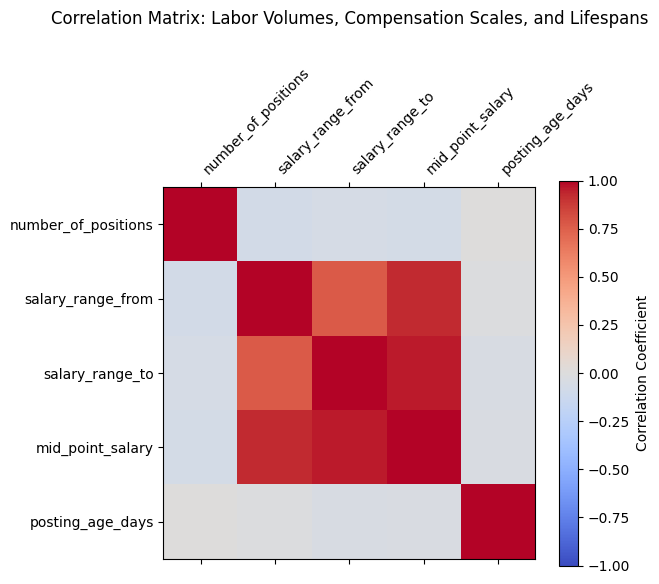

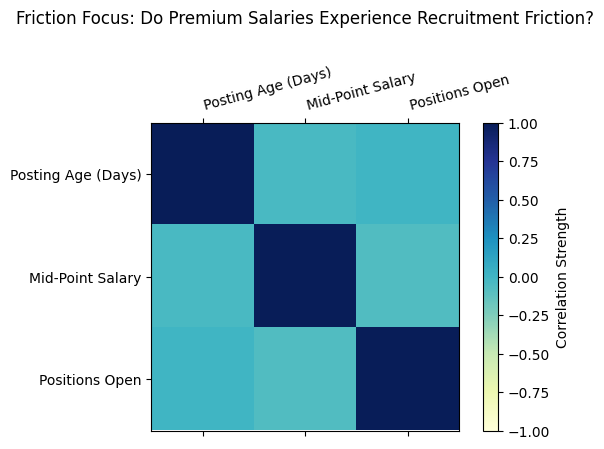

In [85]:
# Isolate annual salaried positions to prevent severe mathematical distortion from hourly rows
annual_salaried_df = restDF[restDF['salary_frequency'] == 'Annual'].copy()

# Calculate the financial mid-point of the advertised salary range
annual_salaried_df['mid_point_salary'] = (annual_salaried_df['salary_range_from'] + annual_salaried_df['salary_range_to']) / 2

# 1. Generate comprehensive Correlation Matrix including labor volume, salary bounds, midpoint, and age
salary_correlation = annual_salaried_df[['number_of_positions', 'salary_range_from', 'salary_range_to', 'mid_point_salary', 'posting_age_days']].corr()

print("Expanded Correlation Matrix (Annual Salaried Cohort Only):")
print(salary_correlation)

# Standard Structural Metric Correlation Heatmap
fig1, ax1 = plt.subplots(figsize=(6, 5))
cax1 = ax1.matshow(salary_correlation, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(cax1, ax=ax1, label="Correlation Coefficient")
ticks = np.arange(0, len(salary_correlation.columns), 1)
ax1.set_xticks(ticks)
ax1.set_xticklabels(salary_correlation.columns, rotation=45, ha='left')
ax1.set_yticks(ticks)
ax1.set_yticklabels(salary_correlation.columns)
ax1.set_title("Correlation Matrix: Labor Volumes, Compensation Scales, and Lifespans", pad=30)
plt.show()

# Market Friction Heatmap Focus
# Specifically isolating market velocity metrics against capital value allocation
velocity_salary_corr = annual_salaried_df[['posting_age_days', 'mid_point_salary', 'number_of_positions']].corr()

fig2, ax2 = plt.subplots(figsize=(6, 4))
cax2 = ax2.matshow(velocity_salary_corr, cmap='YlGnBu', vmin=-1, vmax=1)
plt.colorbar(cax2, ax=ax2, label='Correlation Strength')
ax2.set_xticks(range(3))
ax2.set_xticklabels(['Posting Age (Days)', 'Mid-Point Salary', 'Positions Open'], rotation=15, ha='left')
ax2.set_yticks(range(3))
ax2.set_yticklabels(['Posting Age (Days)', 'Mid-Point Salary', 'Positions Open'])
ax2.set_title("Friction Focus: Do Premium Salaries Experience Recruitment Friction?", pad=30)
plt.show()

*What is the distribution of organizational tiers (career_level) across the city's open positions, and does the municipal hierarchy reflect a flat operational footprint or a top-heavy administrative structure?*

Distribution of Active Vacancies across Hierarchical Tiers:
career_level
Experienced (non-manager)    1740
Entry-Level                   270
Manager                       213
Student                        95
Executive                      44
Name: count, dtype: int64


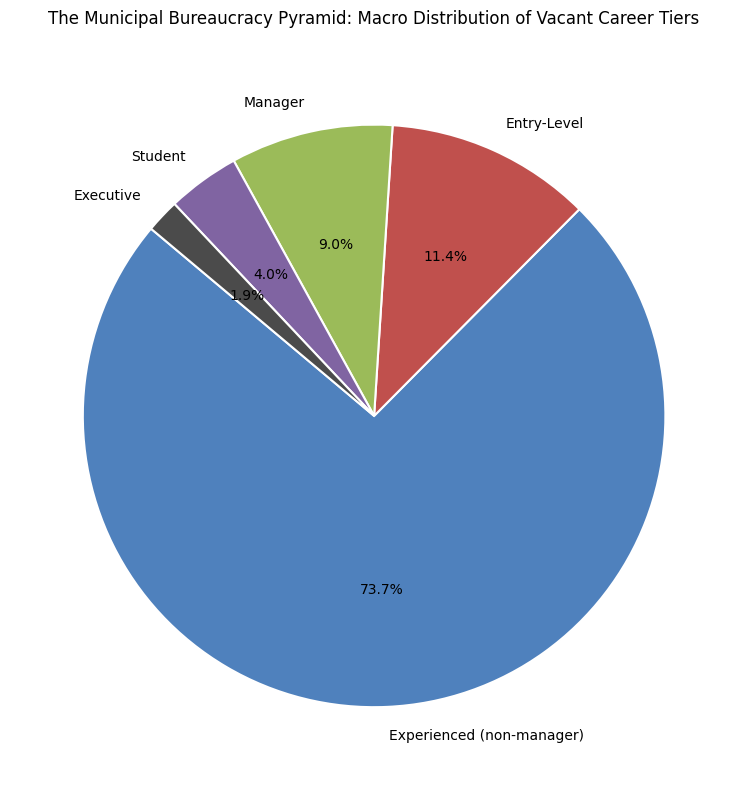

In [86]:
# Tabulate structural frequency across formal civil service tier classes
hierarchy_levels = restDF['career_level'].value_counts()

print("Distribution of Active Vacancies across Hierarchical Tiers:")
print(hierarchy_levels)

# Visualization: Clean Pie Chart tracking the macro shape of organizational demand
plt.figure(figsize=(8, 8))
colors_palette = ['#4f81bd', '#c0504d', '#9bbb59', '#8064a2', '#4b4b4b', '#f79646']
plt.pie(hierarchy_levels, labels=hierarchy_levels.index, autopct='%1.1f%%',
        startangle=140, colors=colors_palette[:len(hierarchy_levels)],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
plt.title("The Municipal Bureaucracy Pyramid: Macro Distribution of Vacant Career Tiers", pad=20)
plt.tight_layout()
plt.show()

*How does the structural mix of 'Internal' versus 'External' job postings vary across different city agencies, and what does this reveal about their talent preservation strategies?*

Recruitment Pipeline Mix Matrix (Top 10 Agencies):
posting_type                    External  Internal
agency                                            
DEPT OF HEALTH/MENTAL HYGIENE        226       226
DEPT OF ENVIRONMENT PROTECTION       110       109
DEPT OF DESIGN & CONSTRUCTION         80        79
DEPARTMENT OF TRANSPORTATION          76        76
HRA/DEPT OF SOCIAL SERVICES           63        63
NYC HOUSING AUTHORITY                 63        61
HOUSING PRESERVATION & DVLPMNT        68        53
BRONX DISTRICT ATTORNEY               40        40
ADMIN FOR CHILDREN'S SVCS             36        36
DISTRICT ATTORNEY-MANHATTAN           36        35


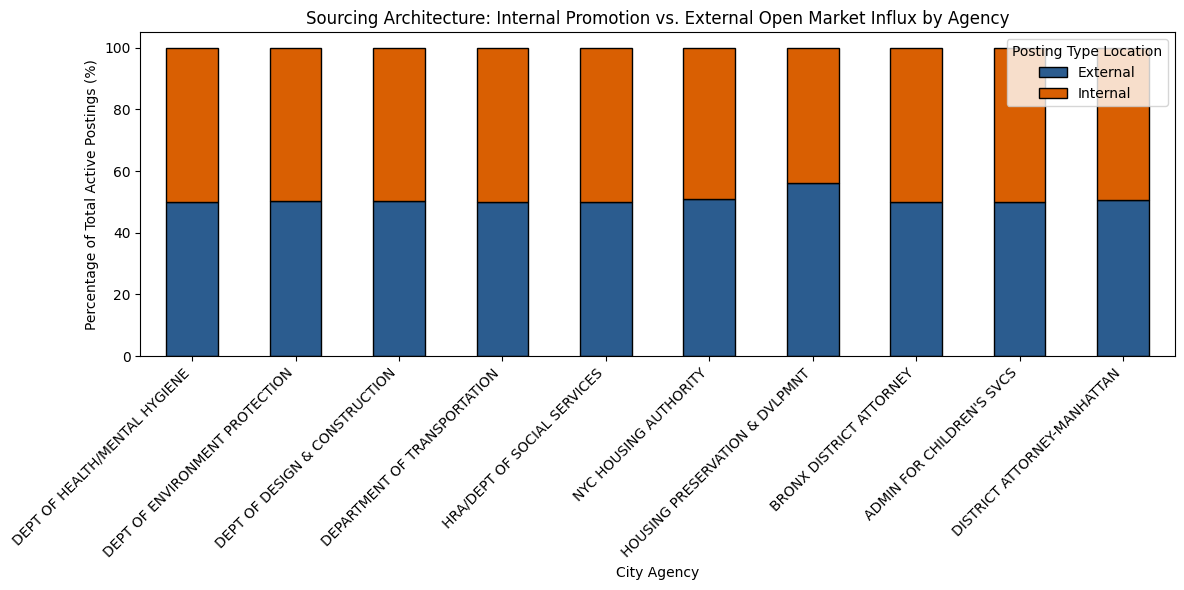

In [87]:
# Generate cross-tabulation of agencies against recruitment channels
pipeline_matrix = restDF.groupby(['agency', 'posting_type']).size().unstack(fill_value=0)

# Filter for the top 10 agencies by total aggregate posting activity to keep plot readable
top_agencies_list = restDF['agency'].value_counts().head(10).index
filtered_pipeline = pipeline_matrix.loc[top_agencies_list]

print("Recruitment Pipeline Mix Matrix (Top 10 Agencies):")
print(filtered_pipeline)

# Visualization: Stacked Percentage Bar Chart to isolate operational strategy
pipeline_percentages = filtered_pipeline.div(filtered_pipeline.sum(axis=1), axis=0) * 100

pipeline_percentages.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2b5c8f', '#d95f02'], edgecolor='black')
plt.xlabel("City Agency")
plt.ylabel("Percentage of Total Active Postings (%)")
plt.title("Sourcing Architecture: Internal Promotion vs. External Open Market Influx by Agency")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Posting Type Location")
plt.tight_layout()
plt.show()

*What is the mathematical spread (Δ=salary_range_to−salary_range_from) across different civil service titles, and what does a wide versus narrow salary band reveal about an agency's pricing flexibility?*

Top 10 Civil Service Titles by Average Salary Spread:
civil_service_title
ASSISTANT DIRECTOR (DEPARTMENT   156675.00
ADMINISTRATIVE DIRECTOR OF RES   155085.00
AGENCY CHIEF CONTRACTING OFFIC   148625.00
ADMINISTRATIVE SUPERINTENDENT    137394.50
ADMINISTRATIVE ENGINEER          133651.00
DIRECTOR OF FIELD OPERATIONS (   126164.00
ASSOCIATE COMMISSIONER (DDC)     125277.00
DEPUTY INSPECTOR GENERAL         120360.50
ADMINISTRATIVE SUPERVISOR OF S   119503.00
INSPECTOR GENERAL                117645.00
Name: salary_spread, dtype: float64


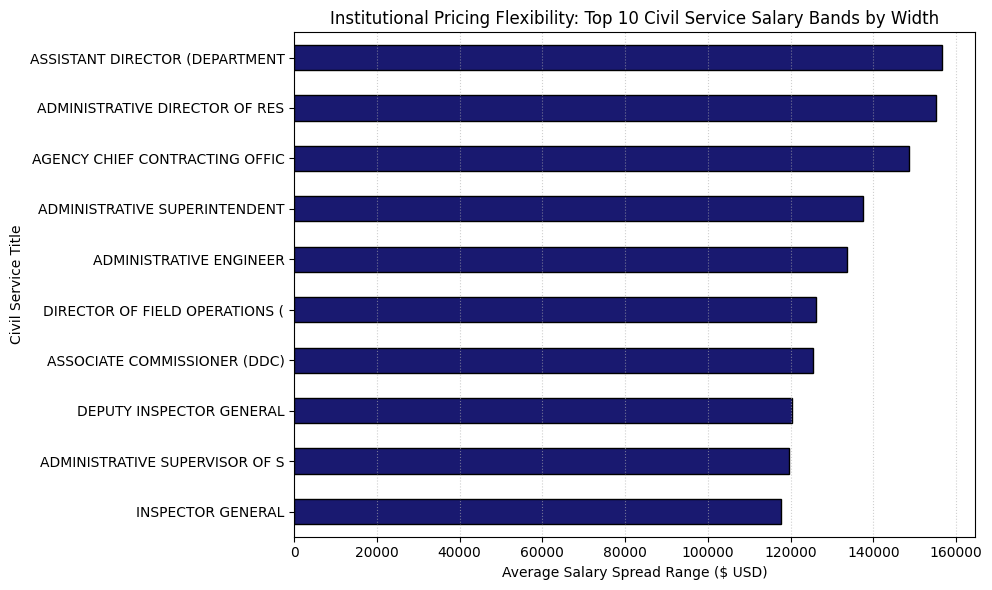

In [88]:
# Isolate annual salaried listings to avoid blending hourly rates with annual wages
annual_jobs = restDF[restDF['salary_frequency'] == 'Annual'].copy()

# Calculate the exact salary spread metric (Delta)
annual_jobs['salary_spread'] = annual_jobs['salary_range_to'] - annual_jobs['salary_range_from']

# Identify titles with the highest pricing discretion (widest bands)
spread_by_title = annual_jobs.groupby('civil_service_title')['salary_spread'].mean().sort_values(ascending=False).head(10)

print("Top 10 Civil Service Titles by Average Salary Spread:")
print(spread_by_title)

# Visualization: Horizontal Bar Chart of Discretionary Spreads
plt.figure(figsize=(10, 6))
spread_by_title.plot(kind='barh', color='midnightblue', edgecolor='black')
plt.gca().invert_yaxis()  # Put the highest spread at the top
plt.xlabel("Average Salary Spread Range ($ USD)")
plt.ylabel("Civil Service Title")
plt.title("Institutional Pricing Flexibility: Top 10 Civil Service Salary Bands by Width")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

*Which job categories or title codes utilize 'bulk-hiring' mechanisms (high values in number_of_positions), and how does this cohort volume contrast against specialized individual vacancy lines?*

Top 10 Job Categories by Total Headcount Allotment:
job_category
Administration & Human Resources                              1305
Legal Affairs                                                 1040
Public Safety, Inspections, & Enforcement                      780
Social Services                                                586
Engineering, Architecture, & Planning                          324
Health                                                         271
Constituent Services & Community Programs                      268
Finance, Accounting, & Procurement                             240
Building Operations & Maintenance                              173
Communications & Intergovernmental Affairs Social Services     140
Name: number_of_positions, dtype: int64


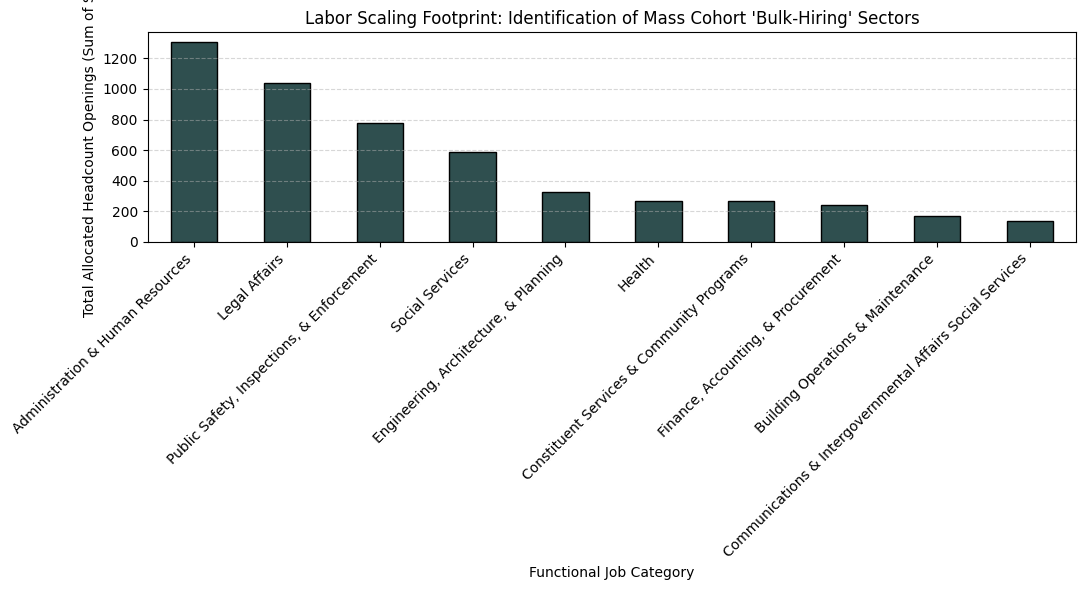

In [89]:
# Aggregate the total volume of individual seats/positions across functional job categories
headcount_demand = restDF.groupby('job_category')['number_of_positions'].sum().sort_values(ascending=False).head(10)

print("Top 10 Job Categories by Total Headcount Allotment:")
print(headcount_demand)

# Visualization: Sorted Horizontal Cohort Volume Bar Chart
plt.figure(figsize=(11, 6))
headcount_demand.plot(kind='bar', color='darkslategrey', edgecolor='black')
plt.xlabel("Functional Job Category")
plt.ylabel("Total Allocated Headcount Openings (Sum of Seats)")
plt.title("Labor Scaling Footprint: Identification of Mass Cohort 'Bulk-Hiring' Sectors")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

*What is the chronological age of active job postings relative to their last structural update, and what does this aging backlog reveal about bureaucratic fulfillment friction?*

Descriptive Statistics of Unfulfilled Posting Durations:
count   2362.00
mean      31.76
std       24.76
min        6.00
25%       16.00
50%       27.00
75%       45.00
max      334.00
Name: posting_age_days, dtype: float64


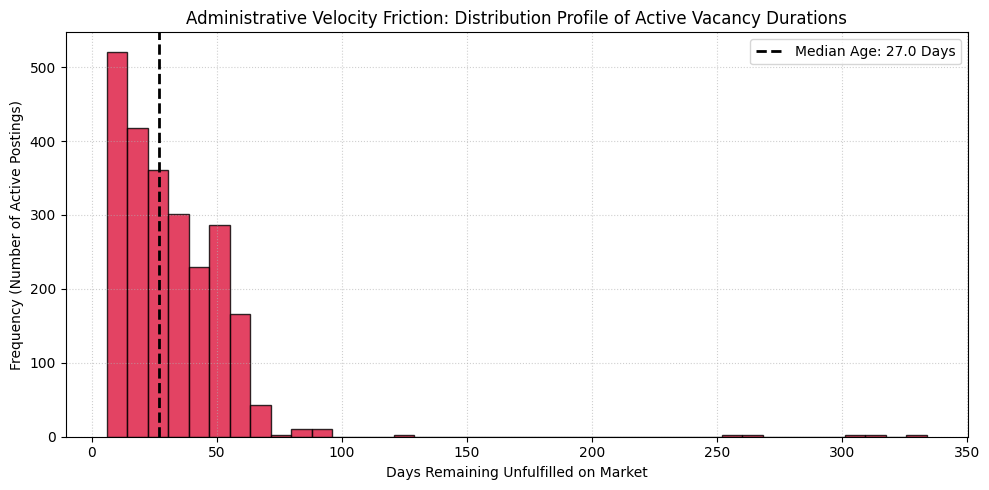

In [90]:
# Establish a fixed temporal assessment point to evaluate active case age
assessment_baseline = pd.to_datetime('2026-05-24')

# Engineer the calculated column: Age of the posting line in days
restDF['posting_age_days'] = (assessment_baseline - restDF['posting_date']).dt.days

print("Descriptive Statistics of Unfulfilled Posting Durations:")
print(restDF['posting_age_days'].describe())

# Visualization: Frequency Distribution Histogram mapping structural backlog skewness
plt.figure(figsize=(10, 5))
plt.hist(restDF['posting_age_days'].dropna(), bins=40, color='crimson', edgecolor='black', alpha=0.8)
plt.axvline(restDF['posting_age_days'].median(), color='black', linestyle='--', linewidth=2, label=f"Median Age: {restDF['posting_age_days'].median():.1f} Days")
plt.xlabel("Days Remaining Unfulfilled on Market")
plt.ylabel("Frequency (Number of Active Postings)")
plt.title("Administrative Velocity Friction: Distribution Profile of Active Vacancy Durations")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Other NYC open datasets that can be combined with this one (kpav-sd4t) to extend the analysis and fields that could be used to do it:

This would mean pivoting from descriptive statistics to macro-level structural analysis. To gauge how effectively the city is utilizing fiscal resources, I suggest:

The Citywide Payroll Data (Fiscal Year 2024 / 2025) dataset (ID 4zc2-cuvr), which could be joined by the "agency" and "agency_name" or "civil_service_title" and "title_description" fields.
The Civil Service List (Active) dataset (ID vx8i-nprf), which could be merged on "civil_service_title" and "list_title_desc".
And the Census Demographics dataset (ID rnsn-acs2), which could be put together via "work_location_borough" and "borough" or "postal_code".

Here is how I would merge it (will return SyntaxError because it is hypothetical code):

In [91]:
merged_labor_df = restDF.merge(
    payrollDF                               # The jobs dataset,
    left_on='title_code_no',                # The external payroll dataset
    right_on='title_code',                  # Key field from job postings
    how='left'                              # Corresponding key from payroll data
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3173883705.py, line 2)

What kind of questions could this answer?

Does the city offer a premium on new listings to compress vacancy rates, or are new hires structurally underpaid relative to the agency average?

Is structural understaffing driving an inefficient reliance on premium-rate overtime spend?

Are long-standing job vacancies a result of a genuine shortage of qualified labor, or is it a failure of agency HR departments to draw from active civil service exam rosters?

What percentage of critical infrastructure or public safety vacancies face severe operational disruption due to impending civil service list expirations?

Do municipal salary bands offered for positions based in the outer boroughs provide a viable economic alternative to local private-sector median incomes, or are they structured to force cross-borough commuting?

Are entry-level, low-barrier municipal job postings strategically distributed to areas experiencing the highest structural unemployment, or are they centralized in administrative hubs?